# LCMV Beamforming

LCMV is MVDR with multiple linear constraints. It is useful when an array should preserve one acoustic direction while placing nulls toward known interferers.

## Math

LCMV extends MVDR to multiple linear constraints. Following PySDR notation, collect steering vectors into a constraint matrix $C$, and choose a desired response vector $f$.

$$
\min_w \; w^H R w
$$

$$
C^H w = f
$$

The PySDR LCMV equation is:

$$
w_{lcmv} = R^{-1} C (C^H R^{-1} C)^{-1} f
$$

$f = [1, 0, 0]^T$ means unit response at the first steering vector and nulls at the next two. PySDR also shows wide beams/nulls by putting several nearby steering vectors into $C$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True


In [2]:
def steering_vector(Nr, d, theta_deg):
    """PySDR-style ULA steering vector. d is measured in wavelengths."""
    theta = np.deg2rad(theta_deg)
    k = np.arange(Nr).reshape(-1, 1)
    s = np.exp(2j * np.pi * d * k * np.sin(theta))
    return s


def complex_noise(shape, rng, power=1.0):
    """Circular complex Gaussian noise with E{|n|^2}=power."""
    return np.sqrt(power / 2) * (
        rng.standard_normal(shape) + 1j * rng.standard_normal(shape)
    )


def simulate_snapshots(Nr, d, thetas_deg, N, source_powers=None, snr_db=20, seed=0):
    """Simulate narrowband far-field snapshots for a ULA.

    Returns X with shape Nr x N, matching the PySDR convention.
    """
    rng = np.random.default_rng(seed)
    thetas_deg = np.asarray(thetas_deg, dtype=float)
    if source_powers is None:
        source_powers = np.ones(len(thetas_deg))
    source_powers = np.asarray(source_powers, dtype=float)

    S_theta = np.hstack([steering_vector(Nr, d, theta) for theta in thetas_deg])
    signals = complex_noise((len(thetas_deg), N), rng)
    signals *= np.sqrt(source_powers).reshape(-1, 1)
    X = S_theta @ signals

    if snr_db is not None:
        signal_power = np.mean(np.abs(X) ** 2)
        noise_power = signal_power / (10 ** (snr_db / 10))
        X = X + complex_noise(X.shape, rng, noise_power)

    return X, S_theta, signals


def sample_covariance(X):
    """Estimate R = (X @ X.conj().T) / N."""
    return (X @ X.conj().T) / X.shape[1]


def to_db(power, floor_db=-80):
    power = np.asarray(power, dtype=float)
    peak = np.max(power)
    floor = peak * (10 ** (floor_db / 10))
    return 10 * np.log10(np.maximum(power, floor) / peak)


In [3]:
Nr = 10
d = 0.5
look_theta = 20
null_thetas = [-35, 55]
constraint_thetas = [look_theta] + null_thetas

X, S_theta, signals = simulate_snapshots(
    Nr,
    d,
    constraint_thetas,
    N=4096,
    source_powers=[1, 4, 4],
    snr_db=20,
    seed=2,
)
R = sample_covariance(X)
Rinv = np.linalg.pinv(R)

C = np.hstack([
    steering_vector(Nr, d, theta)
    for theta in constraint_thetas
])
f = np.array([[1], [0], [0]], dtype=complex)

w_lcmv = Rinv @ C @ np.linalg.pinv(C.conj().T @ Rinv @ C) @ f

for theta, target in zip(constraint_thetas, f.flatten()):
    s = steering_vector(Nr, d, theta)
    gain = (w_lcmv.conj().T @ s).item()
    print(f"{theta:6.1f} deg target {target.real:.1f}, actual {gain.real:+.4f}{gain.imag:+.4f}j")


  20.0 deg target 1.0, actual +1.0000+0.0000j
 -35.0 deg target 0.0, actual -0.0000+0.0000j
  55.0 deg target 0.0, actual -0.0000-0.0000j


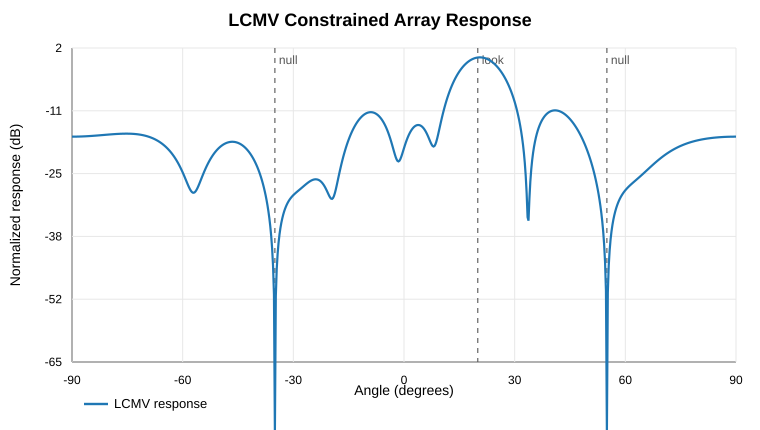

In [4]:
scan_angles = np.linspace(-90, 90, 721)
response = []

for theta in scan_angles:
    s = steering_vector(Nr, d, theta)
    response.append(abs((w_lcmv.conj().T @ s).item()) ** 2)

response_db = to_db(response)

plt.plot(scan_angles, response_db)
plt.axvline(look_theta, color="k", linestyle="--", label="look")
for theta in null_thetas:
    plt.axvline(theta, color="r", linestyle="--", alpha=0.7, label="null")
plt.xlabel("Angle (degrees)")
plt.ylabel("Normalized response (dB)")
plt.title("LCMV Constrained Array Response")
plt.ylim(-65, 2)
plt.legend()
plt.show()


## What to notice

The constraints are exact up to numerical precision: unity gain at the look angle and deep nulls at the constrained interferer angles. LCMV is powerful when those angles are known, but it can be brittle if the constraints are wrong.